In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
class LinearRegression_own:
    def __init__(self) -> None:
        '''
        Constructor for the class
        Defines member variables weights and bias and initializes them to zero
        They can be accessed in other functions of the class by using self.weights and self.bias
        '''
        self.weights: np.ndarray | None = None
        self.bias: float | None = None
    
    def predict(self, X: np.ndarray) -> np.ndarray:
        '''
        Computes the predicted values based on calculated weights and bias given an input array
        
        Args:
            X (np.ndarray): Feature matrix of shape (n_samples, n_features).
        
        Returns:
            An array of predicted values Y_pred (np.ndarray)
        '''
        return np.dot(X,self.weights) + self.bias
    
    
    def __loss(self, X: np.ndarray, y: np.ndarray, norm: int,regularized_lemda : float) -> tuple:
        '''
        The loss function is a variant of Minkowski distance.
        Minkowski distance between X and Y is defined as:
            (1 / n) * [sum(abs(xi - yi) ^ p)]
        Return the loss, and gradients with respect to the weights and bias
        
        Args:
            X_input (np.ndarray): Feature matrix of shape (n_samples, n_features).
            Y_expected (np.ndarray): Target vector of shape (n_samples,).
            norm (int): Order of Minkowski distance.
            regularized(float) : Gives the regualrized lemda value.
        
        Returns:
            tuple: loss, dw, db
        '''

        n = X.shape[0]
        y_pred = self.predict(X)
        diff = y - y_pred
        

        # It is the minkoski loss (norm = p)
        loss = (1/n) * np.sum(np.abs(y - y_pred) ** norm)
        l2_penelty = (regularized_lemda / (2 *n))*(np.sum(np.square(self.weights)))
        loss = loss + l2_penelty

        # only dw is regualized here as regularization of db will not effect much , oftenly not done.

        # Generlly which we used Gradients for MSE (norm = 2)
        if norm ==2:
            dw = (-2 /n) *(X.T  @ (y-y_pred))
            db = (-2/n) * np.sum(y-y_pred)
        else:
            dw = (-norm/n) * (X.T  @(np.abs(diff) ** (norm - 1) * np.sign(diff)))
            db = (-norm/n) * (np.sum(np.abs(diff) ** (norm-1)* np.sign(diff)))
        
        dw_penelty = (regularized_lemda / n)* self.weights
        dw = dw + dw_penelty

        return loss, dw, db
    
    def fit(self, X: np.ndarray, y: np.ndarray, epochs: int = 500, learning_rate: float = 0.01, norm: int = 2, threshold: float = 0.0001, lemda_reg : float = 0.01) -> None:
        '''
        Applies gradient descent on the given data and tunes the values of the weights and bias

        Args:
            X (np.ndarray): Feature matrix of shape (n_samples, n_features).
            y (np.ndarray): Target vector of shape (n_samples,).
            epochs (int): Maximum number of iterations of gradient descent.
            learning_rate (float): Constant which alters the rate of convergence
            norm (int): Norm for the loss function
            threshold (float): Stops the gradient descent if the change in loss or cost is below this value
            lambda_reg (float): Regularization constant (Apply L1 regularization)

        Returns:
            None
        '''
        n_features  = X.shape[1]
        self.weights = np.zeros(n_features)
        self.bias = 0.0

        prev_loss = float('inf')
        # Initialize weights randomly and set up gradient descent
        # YOUR CODE HERE
        
        for _ in range(epochs):
            # Logic for gradient descent (use the loss function to get gradients)
            # YOUR CODE HERE
            loss ,dw , db = self.__loss(X,y,norm , lemda_reg)
            self.weights = self.weights - learning_rate *dw
            self.bias = self.bias - learning_rate * db

            if(abs(prev_loss - loss) <= threshold):
                break

            prev_loss = loss
    
    # more is r2_score more is better model and it will be always b/w 0 and 1
    def r2_score(self, X: np.ndarray, y: np.ndarray) -> float:
        '''
        Calculates the R-squared (coefficient of determination) score of the model.

        Args:
            X (np.ndarray): Feature matrix of shape (n_samples, n_features).
            y (np.ndarray): True target vector of shape (n_samples,).

        Returns:
            float: The R-squared score.
        '''

        y_pred = self.predict(X)

        # Calculate the Total Sum of Squares (SST)
        # This is the variance of the true y values around their mean
        y_mean = np.mean(y)
        sst = np.sum((y - y_mean) ** 2)

        # Calculate the Residual Sum of Squares (SSR)
        # This is the error of our model
        ssr = np.sum((y - y_pred) ** 2)

        # Calculate the R-squared score
        # Add a small epsilon to the denominator to prevent division by zero for constant datasets
        if sst == 0:
            return 1.0 if ssr == 0 else 0.0
        
        r2 = 1 - (ssr / sst)
        
        return r2

In [16]:
df = pd.read_csv('Student_Performance.csv')
activity_map = {'Yes': 1, 'No': 0}
# Apply the mapping to the column
# This will replace 'Yes' with 1 and 'No' with 0
df['Extracurricular Activities'] = df['Extracurricular Activities'].map(activity_map)

X = df.drop(columns=['Performance Index']).to_numpy()
y = df['Performance Index'].to_numpy()



In [17]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [18]:
def z_score(X: np.ndarray) -> tuple:
    '''
    The Z-Score scales data such that its mean is 0 and standard deviation is 1
    z-score for a value x in the dataset is (x - mean) / std_dev
    (z-score normalization is done over a feature and NOT an entry)
    Return the z-score value of all the elements in the set along with the mean and standard deviation of the original set
    '''

    # Add code here
    x_mean = np.mean(X,axis=0) # along each row aas we for each row if we dodn't specified then it would have done whole column
    x_std =np.std(X,axis=0)
    x = (X - x_mean)/x_std
    return x, x_mean, x_std

In [19]:
x_train, x_mean, x_std = z_score(X_train)
x_test = (X_test - x_mean) / x_std

MSE loss:  4.081504922622331
0.9889863225844657


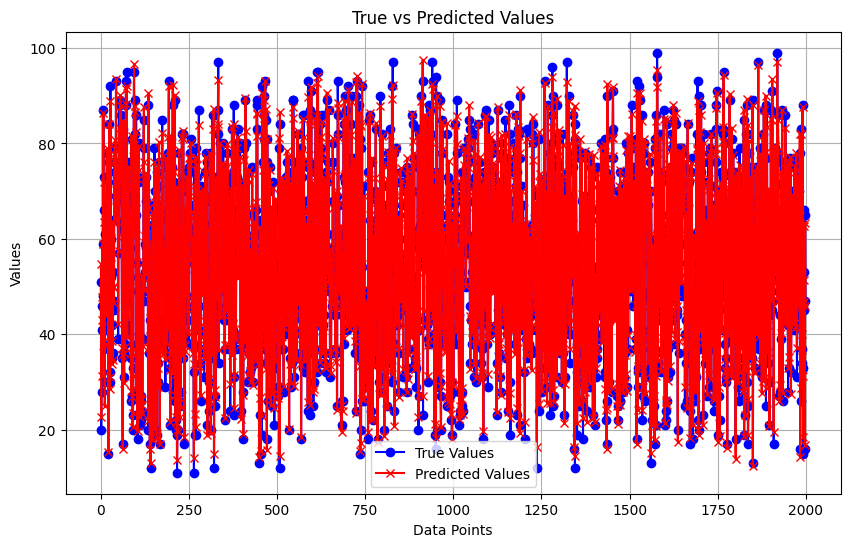

In [20]:
model = LinearRegression_own()
model.fit(x_train, y_train, epochs=500, learning_rate=0.01, norm=2, threshold=0.0001,lemda_reg=0.01)
y_pred = model.predict(x_test)
print("MSE loss: ", np.mean((y_pred - y_test) ** 2))
r2_test = model.r2_score(x_test, y_test)
print(r2_test)

indices = np.arange(len(y_test))
plt.figure(figsize=(10, 6))
plt.plot(indices, y_test, label='True Values', color='blue', marker='o')
plt.plot(indices, y_pred, label='Predicted Values', color='red', marker='x')

plt.xlabel('Data Points')
plt.ylabel('Values')
plt.title('True vs Predicted Values')

plt.legend()
plt.grid(True)
plt.show()



// Now same model from the sklearn

MSE loss:  4.08262839852184
0.9889832909573145


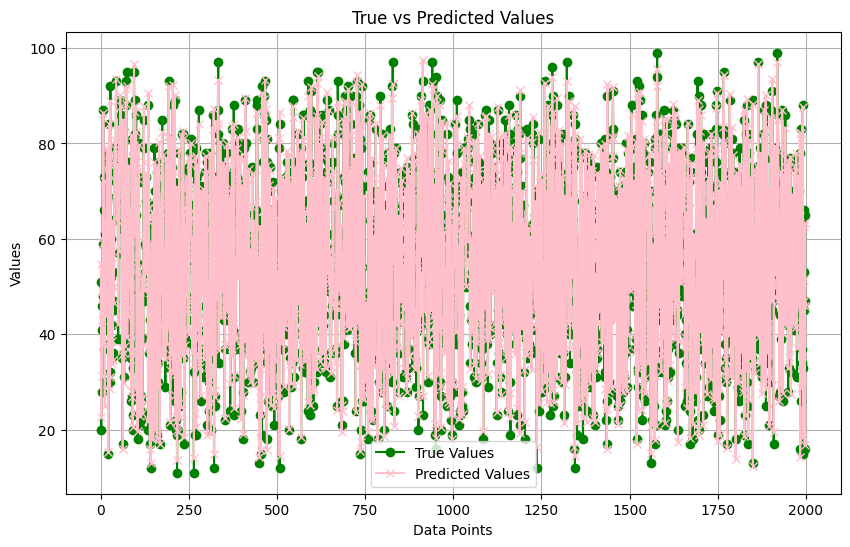

In [29]:
from sklearn.linear_model import LinearRegression


from sklearn.model_selection import train_test_split
X_trainm, X_testm, y_trainm, y_testm = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_trainm)   # Fit on train, transform train
X_test_scaled = scaler.transform(X_testm)         # Transform test using train's mean/std


model.fit(X_train_scaled,y_train)
y_predm = model.predict(X_test_scaled)

print("MSE loss: ", np.mean((y_predm - y_testm) ** 2))
r2_test = model.score(X_test_scaled, y_testm)
print(r2_test)

indices = np.arange(len(y_testm))
plt.figure(figsize=(10, 6))
plt.plot(indices, y_testm, label='True Values', color='green', marker='o')
plt.plot(indices, y_predm, label='Predicted Values', color='pink', marker='x')

plt.xlabel('Data Points')
plt.ylabel('Values')
plt.title('True vs Predicted Values')

plt.legend()
plt.grid(True)
plt.show()

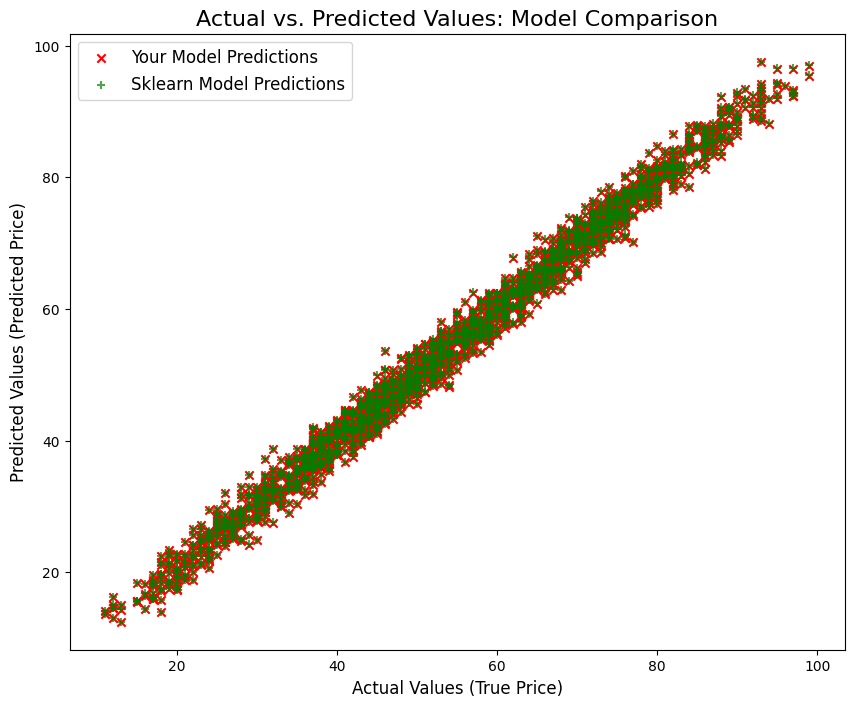

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


# y_testm: The true values for the test set
# y_pred:  The predictions from YOUR custom model
# y_predm: The predictions from the SKLEARN model


plt.figure(figsize=(10, 8))

# 1. model's predictions against the true values
plt.scatter(y_test, y_pred, 
            c='red',              
            marker='x',           
            label='Your Model Predictions')

# 2.  SKLEARN model's predictions against the true values
plt.scatter(y_testm, y_predm, 
            alpha=0.7, 
            c='green',           
            marker='+',           
            label='Sklearn Model Predictions')

plt.xlabel('Actual Values (True Price)', fontsize=12)
plt.ylabel('Predicted Values (Predicted Price)', fontsize=12)
plt.title('Actual vs. Predicted Values: Model Comparison', fontsize=16)
plt.legend(fontsize=12)


# Display the plot
plt.show()

one thing is that i used the the penelty term in linear regression as it was in tutorial tht's why my model is little bit better than sklearn model . <br>
so we can say it is actual liner regression model in a sense it is ridge linear regression model